# Seeds and Augmentation: putting error bars on the headline claim

## 0. Bootstrap

In [1]:
import os, sys, subprocess, glob

ON_KAGGLE = os.path.exists('/kaggle')
BRANCH = 'midterm-prep'
if ON_KAGGLE:
    REPO='/kaggle/working/EXXA'; PKG=os.path.join(REPO,'DENOISING_DIFFUSION')
    if not os.path.exists(REPO):
        subprocess.run(['git','clone','--branch',BRANCH,'--depth','1',
                        'https://github.com/KrishanYadav333/EXXA.git',REPO], check=True)
    else:
        subprocess.run(['git','-C',REPO,'fetch','origin',BRANCH], check=True)
        subprocess.run(['git','-C',REPO,'reset','--hard','origin/'+BRANCH], check=True)
    subprocess.run([sys.executable,'-m','pip','install','-q','--no-deps',
                    'pytorch-msssim','bettermoments'], check=True)
    os.chdir(os.path.join(PKG,'notebooks'));  sys.path.insert(0, PKG)
    hits = glob.glob('/kaggle/input/**/*_dirty.fits', recursive=True)
    DATA_DIR = os.path.dirname(os.path.dirname(hits[0])) if hits else None
else:
    if os.path.basename(os.getcwd()) != 'notebooks' and os.path.isdir('notebooks'): os.chdir('notebooks')
    sys.path.insert(0, os.path.abspath('..'))
    DATA_DIR = '../data/Line Emission Data'
print('cwd:', os.getcwd(), '| DATA_DIR:', DATA_DIR)

Cloning into '/kaggle/working/EXXA'...
Updating files: 100% (5099/5099), done.


cwd: /kaggle/working/EXXA/DENOISING_DIFFUSION/notebooks | DATA_DIR: /kaggle/input/datasets/krishanyadav333/line-emission-data/Line Emission Data


## 0b. Pull latest code (re-run anytime, no kernel restart)

In [2]:
import os, sys, subprocess
ON_KAGGLE = os.path.exists('/kaggle'); REPO = '/kaggle/working/EXXA'; BRANCH = 'midterm-prep'
if ON_KAGGLE and os.path.exists(REPO):
    subprocess.run(['git','-C',REPO,'fetch','origin',BRANCH], check=True)
    subprocess.run(['git','-C',REPO,'reset','--hard','origin/'+BRANCH], check=True)
    print(subprocess.run(['git','-C',REPO,'log','--oneline','-1'],
                         capture_output=True, text=True).stdout.strip())
for _m in [m for m in list(sys.modules) if m == 'src' or m.startswith('src.')]:
    del sys.modules[_m]
print('src.* cleared — re-run the imports cell below.')

From https://github.com/KrishanYadav333/EXXA
 * branch            midterm-prep -> FETCH_HEAD


HEAD is now at eb03589 fix(notebooks): fail loudly when the line-emission Dataset is not attached
eb03589 fix(notebooks): fail loudly when the line-emission Dataset is not attached
src.* cleared — re-run the imports cell below.


## 1. Imports, device, config

In [3]:
import csv, math, time
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from src.data.cube_split import split_cubes
from src.data.fits_cube_dataset import FITSChannelDataset, continuum_of
from src.models.unet import UNet
from src.training.sweep import repeat_config

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_GPU = torch.cuda.device_count()
SEED  = 42
np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
print('device:', device, '| GPUs:', N_GPU,
      '->', [torch.cuda.get_device_name(i) for i in range(N_GPU)] if N_GPU else 'cpu')

TARGET_SIZE, N_SAMPLES = 256, 150
SUBTRACT_CONTINUUM, CONTINUUM_N = True, 5
N_SEEDS = 3                     # floor for a std to mean anything; the std is itself noisy at 3
NW = 2 if ON_KAGGLE else 0
OUT_DIR, CKPT_DIR = '../results', '../results/checkpoints'
os.makedirs(OUT_DIR, exist_ok=True); os.makedirs(CKPT_DIR, exist_ok=True)
# defined here, not at the training cell, because the restore (1b) and CSV-rebuild
# (3b) cells both read it and run first
REPEAT_CSV = os.path.join(OUT_DIR, 'seed_repeats.csv')

V12 = {'psnr': 32.95, 'ssim': 0.9857, 'mse': 0.000681,
       'M0': (69.8, 15.2), 'M1': (17.5, 7.8), 'M2': (20.1, 14.3)}
print(f'{N_SEEDS} seeds per config (configs defined in section 4)')

device: cuda | GPUs: 2 -> ['Tesla T4', 'Tesla T4']
3 seeds per config (configs defined in section 4)


## 1b. Restore a previous session (resume after a timeout)

In [4]:
import glob, shutil

RESTORED = {'csv': 0, 'ckpt': 0}
if ON_KAGGLE:
    # newest match wins, so re-running across several sessions picks the latest state
    csv_hits = sorted(glob.glob('/kaggle/input/**/seed_repeats.csv', recursive=True),
                      key=os.path.getmtime)
    if csv_hits:
        shutil.copy2(csv_hits[-1], REPEAT_CSV)
        RESTORED['csv'] = 1
        print('restored seed_repeats.csv from', csv_hits[-1])

    for src_p in glob.glob('/kaggle/input/**/*_seed*.pth', recursive=True):
        dst = os.path.join(CKPT_DIR, os.path.basename(src_p))
        if not os.path.exists(dst):
            shutil.copy2(src_p, dst)
            RESTORED['ckpt'] += 1
    if RESTORED['ckpt']:
        print(f"restored {RESTORED['ckpt']} checkpoint(s) into {CKPT_DIR}")

if os.path.exists(REPEAT_CSV):
    import pandas as _pd
    _df = _pd.read_csv(REPEAT_CSV)
    _df = _df[_pd.to_numeric(_df.psnr, errors='coerce').notna()]
    print('\ncompleted runs already on record:')
    for tag, grp in _df.groupby('tag'):
        print(f"  {tag:<14} seeds {sorted(int(s) for s in grp.seed)} "
              f"| PSNR {', '.join(f'{p:.3f}' for p in grp.psnr)}")
    print('\nthese will be SKIPPED below; everything else trains normally.')
else:
    print('no previous seed_repeats.csv found — this is a fresh run'
          + (' (add the previous notebook output as an Input to resume)' if ON_KAGGLE else ''))

restored seed_repeats.csv from /kaggle/input/notebooks/krishanyadav333/08-seeds-and-augmentation/EXXA/DENOISING_DIFFUSION/results/seed_repeats.csv
restored 9 checkpoint(s) into ../results/checkpoints

completed runs already on record:
  v12            seeds [42, 43, 44] | PSNR 38.659, 36.671, 37.466
  winner         seeds [42, 43, 44] | PSNR 37.230, 37.724, 38.969
  winner_aug     seeds [42, 43, 44] | PSNR 38.939, 39.808, 39.141

these will be SKIPPED below; everything else trains normally.


## 2. Cube split: held FIXED across every seed

In [5]:
train_cubes, val_cubes, holdout_cubes = split_cubes(data_dir=DATA_DIR, n_holdout=3,
                                                     val_fraction=0.2, seed=SEED)
print('\nsplit is seeded separately and never varies per training seed, so the spread '
      'measured below is training variance on a fixed split.')

CUBE-LEVEL SPLIT (grouped by RunID — no channel-level leakage)
  data_dir          : /kaggle/input/datasets/krishanyadav333/line-emission-data/Line Emission Data
  total cubes       : 14  across 11 distinct RunIDs
  seed=42  n_holdout=3  val_fraction=0.2
----------------------------------------------------------------------
  TRAIN   :  7 cubes | RunIDs ['0006', '0010', '0020', '0022', '0030', '0035']
  VAL     :  2 cubes | RunIDs ['0016', '0036']
  HOLDOUT :  5 cubes | RunIDs ['0002', '0025', '0026']  <-- inference only, NEVER trained/validated
----------------------------------------------------------------------
  HOLDOUT cube folders (reserved for moment-map evaluation):
    - run_0002_00560_rt_00
    - run_0002_00560_rt_01
    - run_0002_00560_rt_04
    - run_0025_01000_rt_04
    - run_0026_00005_rt_04

split is seeded separately and never varies per training seed, so the spread measured below is training variance on a fixed split.


## 3. Datasets: one plain pair, one augmented train set

In [6]:
common = dict(n_samples=N_SAMPLES, target_size=TARGET_SIZE, seed=SEED,
              subtract_continuum=SUBTRACT_CONTINUUM, continuum_n=CONTINUUM_N)
train_ds     = FITSChannelDataset(train_cubes, **common)
train_ds_aug = FITSChannelDataset(train_cubes, augment=True, **common)
val_ds       = FITSChannelDataset(val_cubes,   **common)
print('train:', len(train_ds), '| train(aug):', len(train_ds_aug), '| val:', len(val_ds))

# sanity: augmentation must vary the train item and leave val deterministic
torch.manual_seed(0)
n_orient = len({train_ds_aug[0][0].numpy().tobytes() for _ in range(40)})
val_fixed = len({val_ds[0][0].numpy().tobytes() for _ in range(5)}) == 1
print(f'augmented train item takes {n_orient} distinct orientations | val deterministic: {val_fixed}')
assert n_orient > 1 and val_fixed, 'augmentation wiring is wrong -- stop and fix before training'

[FITSChannelDataset] 7 cubes x ~150 channels = 1050 items | target 256x256 | continuum-subtracted (mean of first/last 5 channels)
[FITSChannelDataset] 7 cubes x ~150 channels = 1050 items | target 256x256 | continuum-subtracted (mean of first/last 5 channels) | D4 augmentation ON
[FITSChannelDataset] 2 cubes x ~150 channels = 300 items | target 256x256 | continuum-subtracted (mean of first/last 5 channels)
train: 1050 | train(aug): 1050 | val: 300
augmented train item takes 8 distinct orientations | val deterministic: True


## 3b. Rebuild `seed_repeats.csv` from checkpoints, if it is missing

In [7]:
from src.training.sweep import val_metrics
from src.training.architectures import build_model

def _rows_in_csv(path):
    if not os.path.exists(path): return set()
    import csv as _csv
    with open(path, newline='') as f:
        return {(r['tag'], int(r['seed'])) for r in _csv.DictReader(f)
                if r.get('seed', '').strip().isdigit() and r.get('psnr')}

have = _rows_in_csv(REPEAT_CSV)
ckpts = sorted(glob.glob(os.path.join(CKPT_DIR, '*_seed*.pth')))
missing = []
for p in ckpts:
    stem = os.path.basename(p)[:-4]                 # e.g. winner_aug_seed43
    tag, _, seed_s = stem.rpartition('_seed')
    if seed_s.isdigit() and (tag, int(seed_s)) not in have:
        missing.append((p, tag, int(seed_s)))

if not missing:
    print(f'{len(ckpts)} checkpoint(s) on disk, {len(have)} CSV row(s) — nothing to rebuild')
else:
    print(f'{len(missing)} checkpoint(s) have no CSV row; re-scoring instead of retraining:')
    fields = ['tag','seed','best_epoch','epochs_run','best_val_loss','psnr','ssim','mse','wall_time_s']
    new_file = not os.path.exists(REPEAT_CSV)
    val_loader = torch.utils.data.DataLoader(val_ds, batch_size=16, shuffle=False,
                                             num_workers=NW)
    with open(REPEAT_CSV, 'a', newline='') as f:
        w = csv.DictWriter(f, fieldnames=fields)
        if new_file: w.writeheader()
        for p, tag, seed in missing:
            ck = torch.load(p, map_location=device, weights_only=False)
            arch = ck.get('arch_key', 'unet')
            net = build_model(arch, base_channels=ck['base_channels'],
                              channel_multipliers=tuple(ck.get('channel_multipliers') or (1,2,4)),
                              use_beam=bool(ck.get('use_beam')),
                              latent_dim=ck.get('latent_dim', 128)).to(device)
            net.load_state_dict(ck['model_state_dict']); net.eval()
            m = val_metrics(net, val_loader, device, use_beam=bool(ck.get('use_beam')), arch=arch)
            w.writerow({'tag': tag, 'seed': seed, 'best_epoch': ck.get('epoch'),
                        'epochs_run': '', 'best_val_loss': ck.get('val_loss'),
                        'psnr': m['psnr'], 'ssim': m['ssim'], 'mse': m['mse'],
                        'wall_time_s': ''})
            f.flush()
            print(f"  {tag:<14} seed {seed}: epoch {ck.get('epoch')} | "
                  f"PSNR {m['psnr']:.4f} | SSIM {m['ssim']:.4f}  (re-scored)")
            del net
            if torch.cuda.is_available(): torch.cuda.empty_cache()
    print('\nCSV rebuilt — these arms will now be SKIPPED by resume.')

9 checkpoint(s) on disk, 9 CSV row(s) — nothing to rebuild


## 4. The four configurations

In [8]:
# schedule lives inside each config so `winner_p10` can differ on patience alone
SCHED = dict(min_epochs=20, max_epochs=60, patience=5)

CONFIGS = {
    'v12':    dict(base_channels=32, channel_multipliers=(1, 2, 4),
                   lr=1e-3, alpha=0.8, sched_patience=5, use_beam=False,
                   batch_size=32, **SCHED),
    'winner': dict(base_channels=48, channel_multipliers=(1, 2, 4, 8),
                   lr=0.0008196504330730313, alpha=0.8877681051398497,
                   sched_patience=8, use_beam=False, batch_size=16, **SCHED),
}
CONFIGS['winner_aug'] = dict(CONFIGS['winner'])                    # + augmented train set
CONFIGS['winner_p10'] = dict(CONFIGS['winner'], patience=10)       # + looser early stopping

DATASETS = {'v12': train_ds, 'winner': train_ds,
            'winner_aug': train_ds_aug, 'winner_p10': train_ds}

for name, cfg in CONFIGS.items():
    aug = ' [augmented]' if DATASETS[name] is train_ds_aug else ''
    print(f"{name:<12} patience={cfg['patience']:<3} base={cfg['base_channels']:<3} "
          f"mult={cfg['channel_multipliers']}{aug}")
print(f'\n{len(CONFIGS)} configs x {N_SEEDS} seeds = {len(CONFIGS)*N_SEEDS} training runs')

v12          patience=5   base=32  mult=(1, 2, 4)
winner       patience=5   base=48  mult=(1, 2, 4, 8)
winner_aug   patience=5   base=48  mult=(1, 2, 4, 8) [augmented]
winner_p10   patience=10  base=48  mult=(1, 2, 4, 8)

4 configs x 3 seeds = 12 training runs


## 5. Train: 4 configs x 3 seeds

In [9]:
results = {}
t_all = time.time()

for name, cfg in CONFIGS.items():
    t0 = time.time()
    results[name] = repeat_config(
        DATASETS[name], val_ds, device,
        n_seeds=N_SEEDS, base_seed=SEED, out_csv=REPEAT_CSV, ckpt_dir=CKPT_DIR,
        tag=name, num_workers=NW, resume=True, verbose=True, **cfg)
    print(f'--- {name} finished in {(time.time()-t0)/60:.1f} min ---\n', flush=True)

print(f'all {len(CONFIGS)*N_SEEDS} runs in {(time.time()-t_all)/60:.1f} min -> {REPEAT_CSV}')

  [resume] reusing 3 completed seed(s) for 'v12': [42, 43, 44]
=== repeating 'v12' over 3 seeds (split held fixed; only training seed varies) ===
--- v12: seed 42 (1/3) SKIPPED, already done (PSNR 38.6593) ---
--- v12: seed 43 (2/3) SKIPPED, already done (PSNR 36.6707) ---
--- v12: seed 44 (3/3) SKIPPED, already done (PSNR 37.4657) ---

=== 'v12' over 3 seeds ===
  PSNR  37.5986 +/- 1.0009  (values: 38.6593, 36.6707, 37.4657)
  SSIM  0.9922 +/- 0.0011  (values: 0.9934, 0.9912, 0.9920)
  MSE   0.0003 +/- 0.0001  (values: 0.0002, 0.0003, 0.0003)
--- v12 finished in 0.0 min ---

  [resume] reusing 3 completed seed(s) for 'winner': [42, 43, 44]
=== repeating 'winner' over 3 seeds (split held fixed; only training seed varies) ===
--- winner: seed 42 (1/3) SKIPPED, already done (PSNR 37.2303) ---
--- winner: seed 43 (2/3) SKIPPED, already done (PSNR 37.7237) ---
--- winner: seed 44 (3/3) SKIPPED, already done (PSNR 38.9694) ---

=== 'winner' over 3 seeds ===
  PSNR  37.9745 +/- 0.8962  (valu

## 6. Channel-level comparison, with error bars

In [10]:
print('=' * 88)
print('{:<14} {:>22} {:>20} {:>22}'.format('config', 'PSNR (dB)', 'SSIM', 'MSE'))
print('-' * 88)
for name in CONFIGS:
    r = results[name]
    print('{:<14} {:>13.4f} +/- {:<6.4f} {:>11.4f} +/- {:<6.4f} {:>12.6f} +/- {:<8.6f}'.format(
        name, r['psnr']['mean'], r['psnr']['std'],
        r['ssim']['mean'], r['ssim']['std'], r['mse']['mean'], r['mse']['std']))
print('{:<14} {:>13.4f} {:>7} {:>11.4f} {:>7} {:>12.6f}'.format(
    'V12 (published)', V12['psnr'], '(n=1)', V12['ssim'], '(n=1)', V12['mse']))
print('=' * 88)

def verdict(a, b, name_a, name_b):
    """Compare two repeated configs, refusing to call a gap real if the spreads overlap."""
    ma, sa = a['psnr']['mean'], a['psnr']['std']
    mb, sb = b['psnr']['mean'], b['psnr']['std']
    gap = ma - mb
    pooled = float(np.sqrt(sa ** 2 + sb ** 2)) or 1e-12
    print(f'\n{name_a} - {name_b}: {gap:+.3f} dB  (spreads {sa:.3f} / {sb:.3f}, '
          f'combined {pooled:.3f})')
    if abs(gap) > 2 * pooled:
        print(f'  -> gap exceeds 2x the combined spread: treat as REAL')
    elif abs(gap) > pooled:
        print(f'  -> gap is 1-2x the combined spread: SUGGESTIVE, not established at n={N_SEEDS}')
    else:
        print(f'  -> gap is within the combined spread: INDISTINGUISHABLE from seed noise')
    return gap, pooled

verdict(results['winner'], results['v12'], 'winner', 'v12')
verdict(results['winner_aug'], results['winner'], 'winner_aug', 'winner')
verdict(results['winner_p10'], results['winner'], 'winner_p10', 'winner')

print('\nNOTE: with n=3 the std is itself a noisy estimate. These thresholds are a guard '
      'against over-claiming, not a significance test.')

config                      PSNR (dB)                 SSIM                    MSE
----------------------------------------------------------------------------------------
v12                  37.5986 +/- 1.0009      0.9922 +/- 0.0011     0.000283 +/- 0.000053
winner               37.9745 +/- 0.8962      0.9926 +/- 0.0003     0.000271 +/- 0.000018
winner_aug           39.2962 +/- 0.4550      0.9929 +/- 0.0005     0.000230 +/- 0.000025
winner_p10           39.2727 +/- 0.4842      0.9938 +/- 0.0004     0.000212 +/- 0.000022
V12 (published)       32.9500   (n=1)      0.9857   (n=1)     0.000681

winner - v12: +0.376 dB  (spreads 0.896 / 1.001, combined 1.344)
  -> gap is within the combined spread: INDISTINGUISHABLE from seed noise

winner_aug - winner: +1.322 dB  (spreads 0.455 / 0.896, combined 1.005)
  -> gap is 1-2x the combined spread: SUGGESTIVE, not established at n=3

winner_p10 - winner: +1.298 dB  (spreads 0.484 / 0.896, combined 1.019)
  -> gap is 1-2x the combined spread: SUGGE

## 6b. Was V16's shortfall an early-stopping artifact?

In [11]:
import math

def pearson(x, y):
    n = len(x)
    if n < 2: return float('nan')
    mx, my = sum(x)/n, sum(y)/n
    cov = sum((a-mx)*(b-my) for a, b in zip(x, y))
    sx = math.sqrt(sum((a-mx)**2 for a in x)); sy = math.sqrt(sum((b-my)**2 for b in y))
    return cov/(sx*sy) if sx > 0 and sy > 0 else float('nan')

print('epochs_run vs PSNR, per config (does a longer run score better?)')
print('-' * 74)
all_ep, all_ps = [], []
for name in CONFIGS:
    ep = [r['epochs_run'] for r in results[name]['rows']]
    ps = [r['psnr'] for r in results[name]['rows']]
    all_ep += ep; all_ps += ps
    print('{:<12} epochs {:<22} PSNR {:<26} r={:+.3f}'.format(
        name, ', '.join(str(int(e)) for e in ep),
        ', '.join(f'{p:.2f}' for p in ps), pearson(ep, ps)))
print('-' * 74)
print('{:<12} pooled over all {} runs{:>34}r={:+.3f}'.format(
    'ALL', len(all_ep), '', pearson(all_ep, all_ps)))
print('  (sweep reference: r = +0.650 over its 12 runs)')

w, p10 = results['winner'], results['winner_p10']
ep_w = float(np.mean([r['epochs_run'] for r in w['rows']]))
ep_p = float(np.mean([r['epochs_run'] for r in p10['rows']]))
print(f'\npatience 5  -> mean {ep_w:.1f} epochs, PSNR {w["psnr"]["mean"]:.3f} '
      f'+/- {w["psnr"]["std"]:.3f}')
print(f'patience 10 -> mean {ep_p:.1f} epochs, PSNR {p10["psnr"]["mean"]:.3f} '
      f'+/- {p10["psnr"]["std"]:.3f}')
print(f'  extra epochs bought: {ep_p - ep_w:+.1f}   PSNR change: '
      f'{p10["psnr"]["mean"] - w["psnr"]["mean"]:+.3f} dB')
print(f'  variance change: std {w["psnr"]["std"]:.3f} -> {p10["psnr"]["std"]:.3f}')

SWEEP_PSNR = 37.109
print(f'\nsweep recorded {SWEEP_PSNR:.2f} dB for this config; V16 retrain got 30.28 dB.')
gap_closed = (p10['psnr']['mean'] - w['psnr']['mean']) / (SWEEP_PSNR - w['psnr']['mean']) \
    if SWEEP_PSNR > w['psnr']['mean'] else float('nan')
if np.isfinite(gap_closed):
    print(f'looser early stopping closes {gap_closed:.0%} of the gap to the sweep number.')
print('  >50% closed  -> the shortfall was largely an early-stopping artifact;')
print('  <20% closed  -> the configuration genuinely is not better and 37.11 dB was luck.')

epochs_run vs PSNR, per config (does a longer run score better?)
--------------------------------------------------------------------------
v12          epochs 60, 22, 26             PSNR 38.66, 36.67, 37.47        r=+0.952
winner       epochs 26, 28, 28             PSNR 37.23, 37.72, 38.97        r=+0.719
winner_aug   epochs 31, 51, 34             PSNR 38.94, 39.81, 39.14        r=+0.996
winner_p10   epochs 40, 45, 60             PSNR 38.95, 39.03, 39.83        r=+0.987
--------------------------------------------------------------------------
ALL          pooled over all 12 runs                                  r=+0.721
  (sweep reference: r = +0.650 over its 12 runs)

patience 5  -> mean 27.3 epochs, PSNR 37.974 +/- 0.896
patience 10 -> mean 48.3 epochs, PSNR 39.273 +/- 0.484
  extra epochs bought: +21.0   PSNR change: +1.298 dB
  variance change: std 0.896 -> 0.484

sweep recorded 37.11 dB for this config; V16 retrain got 30.28 dB.
  >50% closed  -> the shortfall was largely an ear

## 7. Loss curves: all seeds, all configs

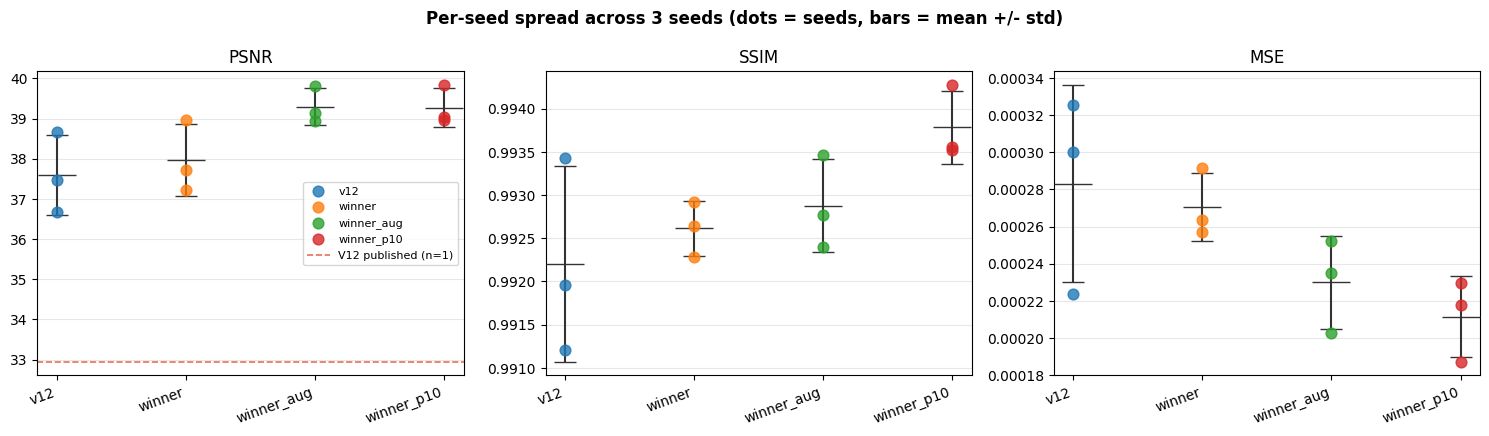

saved -> ../results/seed_spread.png


In [12]:
import pandas as pd
df = pd.read_csv(REPEAT_CSV)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, metric in zip(axes, ['psnr', 'ssim', 'mse']):
    for i, name in enumerate(CONFIGS):
        sub = df[df.tag == name]
        ax.scatter([i] * len(sub), sub[metric], s=60, alpha=0.8, zorder=5,
                   label=name if metric == 'psnr' else None)
        ax.errorbar(i, sub[metric].mean(), yerr=sub[metric].std(ddof=1),
                    fmt='_', ms=28, capsize=8, color='#333', zorder=4)
    if metric == 'psnr':
        ax.axhline(V12['psnr'], ls='--', color='#E8715A', lw=1.2, label='V12 published (n=1)')
        ax.legend(fontsize=8)
    ax.set_xticks(range(len(CONFIGS))); ax.set_xticklabels(list(CONFIGS), rotation=20, ha='right')
    ax.set_title(metric.upper()); ax.grid(axis='y', alpha=0.3)
fig.suptitle(f'Per-seed spread across {N_SEEDS} seeds (dots = seeds, bars = mean +/- std)',
             fontweight='bold')
plt.tight_layout()
p = os.path.join(OUT_DIR, 'seed_spread.png'); plt.savefig(p, dpi=140); plt.show()
print('saved ->', p)

## 8. Moment-map protocol on the best seed of each config

In [13]:
import bettermoments as bm
from astropy.io import fits
from src.evaluation.moment_maps import generate_moment_maps
from src.evaluation.classical import summarise_improvements

BS = 32
moments = ['M0', 'M1', 'M2']

def mdiff(a, b):
    m = np.isfinite(a) & np.isfinite(b)
    return float(np.nanmean(np.abs(a[m] - b[m])))

def load_net(ckpt_path):
    ck = torch.load(ckpt_path, map_location=device, weights_only=False)
    net = UNet(in_channels=1, out_channels=1, base_channels=ck['base_channels'],
               channel_multipliers=ck['channel_multipliers'], time_emb_dim=128,
               num_res_blocks=2, groups=math.gcd(8, ck['base_channels']),
               beam_dim=ck.get('beam_dim', 0)).to(device)
    net.load_state_dict(ck['model_state_dict']); net.eval()
    return net, ck

def denoise_cube_unet(ho, net):
    with fits.open(ho['dirty'], memmap=False) as h:
        raw = np.ascontiguousarray(h[0].data).astype(np.float32)
    csub = raw - continuum_of(raw, CONTINUUM_N)[None]
    C, H, W = csub.shape
    lo = csub.reshape(C, -1).min(axis=1); hi = csub.reshape(C, -1).max(axis=1)
    rng_ = hi - lo; nz = rng_ > 0
    norm = np.zeros_like(csub)
    norm[nz] = (csub[nz] - lo[nz, None, None]) / rng_[nz, None, None]
    out = np.empty_like(csub)
    with torch.no_grad():
        for s in range(0, C, BS):
            t = torch.from_numpy(norm[s:s+BS])[:, None].to(device)
            t256 = F.interpolate(t, (TARGET_SIZE, TARGET_SIZE), mode='bilinear', align_corners=False)
            tz = torch.zeros(t256.size(0), dtype=torch.long, device=device)
            pred = net(t256, tz)
            back = F.interpolate(pred, (H, W), mode='bilinear', align_corners=False)[:, 0].cpu().numpy()
            for k in range(back.shape[0]):
                ch = s + k
                out[ch] = back[k] * rng_[ch] + lo[ch] if rng_[ch] > 0 else np.full((H, W), lo[ch], np.float32)
    return out, csub

# cache clean/dirty moment maps once; reused by all three configs
cache = {}
for ho in holdout_cubes:
    with fits.open(ho['clean'], memmap=False) as h:
        craw = np.ascontiguousarray(h[0].data).astype(np.float32)
    ccsub = craw - continuum_of(craw, CONTINUUM_N)[None]
    with fits.open(ho['dirty'], memmap=False) as h:
        draw = np.ascontiguousarray(h[0].data).astype(np.float32)
    dcsub = draw - continuum_of(draw, CONTINUUM_N)[None]
    _, velax = bm.load_cube(ho['dirty'])
    cache[ho['folder']] = {'velax': velax,
                           'clean': generate_moment_maps(None, data_velax=(ccsub, velax)),
                           'dirty': generate_moment_maps(None, data_velax=(dcsub, velax))}
print('cached clean/dirty moment maps for', len(cache), 'cubes')

moment_summaries, moment_rows = {}, {}
for name in CONFIGS:
    best_seed = int(max(results[name]['rows'], key=lambda r: r['psnr'])['seed'])
    ckpt = os.path.join(CKPT_DIR, f'{name}_seed{best_seed}.pth')
    net, ck = load_net(ckpt)
    print(f'\n=== {name} (best seed {best_seed}, epoch {ck.get("epoch")}) ===', flush=True)
    rows = []
    for ho in holdout_cubes:
        den, _ = denoise_cube_unet(ho, net)
        e = cache[ho['folder']]
        no = generate_moment_maps(None, data_velax=(den, e['velax']))
        row = {'cube': ho['folder'], 'seed': best_seed}
        for nm, cl, di, n_ in zip(moments, e['clean'], e['dirty'], no):
            dd, nn = mdiff(cl, di), mdiff(cl, n_)
            row['imp_' + nm] = round(100.0 * (1 - nn / dd), 2) if dd > 0 else float('nan')
        rows.append(row)
        print('  {:<24} M0 {:>7.1f}%  M1 {:>7.1f}%  M2 {:>7.1f}%'.format(
            ho['folder'], row['imp_M0'], row['imp_M1'], row['imp_M2']))
    moment_rows[name] = rows
    moment_summaries[name] = summarise_improvements(rows)
    s = moment_summaries[name]
    print('  -> ' + '  '.join(f'{m} {s[m]["mean"]:+.1f}%+/-{s[m]["std"]:.1f}' for m in moments))
    del net
    if torch.cuda.is_available(): torch.cuda.empty_cache()

cached clean/dirty moment maps for 5 cubes

=== v12 (best seed 42, epoch 59) ===
  run_0002_00560_rt_00     M0    75.0%  M1    22.1%  M2    13.6%
  run_0002_00560_rt_01     M0    77.2%  M1    28.7%  M2    23.5%
  run_0002_00560_rt_04     M0    95.0%  M1    11.8%  M2    17.7%
  run_0025_01000_rt_04     M0    86.2%  M1    57.6%  M2    54.7%
  run_0026_00005_rt_04     M0    76.4%  M1    20.9%  M2    22.6%
  -> M0 +82.0%+/-8.5  M1 +28.2%+/-17.5  M2 +26.4%+/-16.3

=== winner (best seed 44, epoch 23) ===
  run_0002_00560_rt_00     M0    93.5%  M1    27.4%  M2    17.8%
  run_0002_00560_rt_01     M0    78.4%  M1    35.5%  M2    19.8%
  run_0002_00560_rt_04     M0    96.2%  M1    11.5%  M2    17.2%
  run_0025_01000_rt_04     M0    84.5%  M1    49.6%  M2    57.1%
  run_0026_00005_rt_04     M0    74.8%  M1    21.3%  M2    23.4%
  -> M0 +85.5%+/-9.3  M1 +29.1%+/-14.5  M2 +27.0%+/-17.0

=== winner_aug (best seed 43, epoch 46) ===
  run_0002_00560_rt_00     M0    89.5%  M1    28.4%  M2    13.0%
  ru

## 9. Final table: the midterm's decisive comparison

In [14]:
print('=' * 96)
print('{:<20} {:>14} {:>18} {:>18} {:>18}'.format('config', 'PSNR (dB)', 'M0 (%)', 'M1 (%)', 'M2 (%)'))
print('-' * 96)
for name in CONFIGS:
    s, r = moment_summaries[name], results[name]
    print('{:<20} {:>8.2f}+/-{:<4.2f} {:>10.1f} +/-{:<5.1f} {:>10.1f} +/-{:<5.1f} {:>10.1f} +/-{:<5.1f}'.format(
        name, r['psnr']['mean'], r['psnr']['std'],
        s['M0']['mean'], s['M0']['std'], s['M1']['mean'], s['M1']['std'],
        s['M2']['mean'], s['M2']['std']))
print('{:<20} {:>8.2f}{:>6} {:>10.1f} +/-{:<5.1f} {:>10.1f} +/-{:<5.1f} {:>10.1f} +/-{:<5.1f}'.format(
    'V12 (published)', V12['psnr'], '(n=1)',
    V12['M0'][0], V12['M0'][1], V12['M1'][0], V12['M1'][1], V12['M2'][0], V12['M2'][1]))
print('{:<20} {:>8} {:>6} {:>10.1f} +/-{:<5.1f} {:>10.1f} +/-{:<5.1f} {:>10.1f} +/-{:<5.1f}'.format(
    'U-Net + beam', '34.94', '(n=1)', 59.8, 33.0, 19.2, 8.4, 23.2, 20.2))
print('=' * 96)

print('\nPromotion check — a config is only promoted if it wins on the SCIENTIFIC metric:')
ref = moment_summaries['v12']
for name in ('winner', 'winner_aug'):
    s = moment_summaries[name]
    print(f'\n  {name} vs v12 (this notebook, matched schedule):')
    for m in moments:
        gap = s[m]['mean'] - ref[m]['mean']
        pooled = float(np.sqrt(s[m]['std'] ** 2 + ref[m]['std'] ** 2)) or 1e-12
        flag = 'REAL' if abs(gap) > 2 * pooled else ('suggestive' if abs(gap) > pooled else 'within noise')
        print(f'    {m}: {gap:+6.1f} pp  (cube-to-cube spread {pooled:.1f} pp) -> {flag}')

csv_path = os.path.join(OUT_DIR, 'seed_moment_summary.csv')
with open(csv_path, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['config', 'seed', 'cube', 'imp_M0', 'imp_M1', 'imp_M2'])
    for name, rows in moment_rows.items():
        for r in rows:
            w.writerow([name, r['seed'], r['cube'], r['imp_M0'], r['imp_M1'], r['imp_M2']])
        s = moment_summaries[name]
        w.writerow([name, '', 'MEAN'] + [round(s[m]['mean'], 2) for m in moments])
        w.writerow([name, '', 'STD'] + [round(s[m]['std'], 2) for m in moments])
print('\nsaved ->', csv_path)

config                    PSNR (dB)             M0 (%)             M1 (%)             M2 (%)
------------------------------------------------------------------------------------------------
v12                     37.60+/-1.00       82.0 +/-8.5         28.2 +/-17.5        26.4 +/-16.3 
winner                  37.97+/-0.90       85.5 +/-9.3         29.1 +/-14.5        27.0 +/-17.0 
winner_aug              39.30+/-0.46       87.5 +/-4.2         25.4 +/-26.4        26.7 +/-19.7 
winner_p10              39.27+/-0.48       85.8 +/-6.6         35.9 +/-10.9        24.1 +/-17.3 
V12 (published)         32.95 (n=1)       69.8 +/-15.2        17.5 +/-7.8         20.1 +/-14.3 
U-Net + beam            34.94  (n=1)       59.8 +/-33.0        19.2 +/-8.4         23.2 +/-20.2 

Promotion check — a config is only promoted if it wins on the SCIENTIFIC metric:

  winner vs v12 (this notebook, matched schedule):
    M0:   +3.5 pp  (cube-to-cube spread 12.6 pp) -> within noise
    M1:   +0.9 pp  (cube-to-cu

## 10. Artifact diagnostics: did augmentation reduce invented structure?

In [15]:
from src.evaluation.artifacts import channel_artifacts, summarise

# The hallucination artifact was attributed to small data, which is exactly what
# augmentation is supposed to mitigate. This measures it rather than assuming it.
art = {}
for name in CONFIGS:
    best_seed = int(max(results[name]['rows'], key=lambda r: r['psnr'])['seed'])
    net, _ = load_net(os.path.join(CKPT_DIR, f'{name}_seed{best_seed}.pth'))
    rows = []
    with torch.no_grad():
        for i in range(len(val_ds)):
            d, c = val_ds[i]
            pred = net(d[None].to(device), torch.zeros(1, dtype=torch.long, device=device))
            cl = c[0].numpy()
            if cl.max() <= 0:
                continue
            rows.append(channel_artifacts(cl, d[0].numpy(), pred[0, 0].cpu().numpy()))
    art[name] = summarise(rows)
    a = art[name]
    print(f'{name:<12} overshoot {a["overshoot_mean"]:.3f} | floor leak {a["floor_leak_mean"]:+.5f} '
          f'| channels with invented blob {a["frac_channels_with_blob"]:.1%} '
          f'| blobs/channel {a["blobs_per_channel"]:.3f}')
    if 'low_snr_blobs_per_channel' in a:
        print(f'{"":12} low-SNR blobs/ch {a["low_snr_blobs_per_channel"]:.3f} vs '
              f'high-SNR {a["high_snr_blobs_per_channel"]:.3f} (split at SNR {a["snr_median"]:.1f})')
    del net
    if torch.cuda.is_available(): torch.cuda.empty_cache()

base = art['winner']['frac_channels_with_blob']
aug  = art['winner_aug']['frac_channels_with_blob']
print(f'\naugmentation effect on invented structure: {base:.1%} -> {aug:.1%} of channels '
      f'({aug - base:+.1%} pp)')

art_csv = os.path.join(OUT_DIR, 'artifact_diagnostics_seeds.csv')
keys = sorted({k for a in art.values() for k in a})
with open(art_csv, 'w', newline='') as f:
    w = csv.writer(f); w.writerow(['config'] + keys)
    for name, a in art.items():
        w.writerow([name] + [a.get(k, '') for k in keys])
print('saved ->', art_csv)

v12          overshoot 0.930 | floor leak +0.28349 | channels with invented blob 0.0% | blobs/channel 0.000
winner       overshoot 0.895 | floor leak +0.20985 | channels with invented blob 0.0% | blobs/channel 0.000
winner_aug   overshoot 0.921 | floor leak +0.33865 | channels with invented blob 0.0% | blobs/channel 0.000
winner_p10   overshoot 0.891 | floor leak +0.23865 | channels with invented blob 0.0% | blobs/channel 0.000

augmentation effect on invented structure: 0.0% -> 0.0% of channels (+0.0% pp)
saved -> ../results/artifact_diagnostics_seeds.csv


## 11. Persist artifacts to /kaggle/working

In [16]:
import shutil
if ON_KAGGLE:
    # every per-seed checkpoint, not just the best: a resumed session needs the
    # completed arms' checkpoints to run their moment maps without retraining
    import glob as _glob
    wanted = [REPEAT_CSV, csv_path, art_csv,
              os.path.join(OUT_DIR, 'seed_spread.png')]
    wanted += sorted(_glob.glob(os.path.join(CKPT_DIR, '*_seed*.pth')))
    for p in wanted:
        if os.path.exists(p):
            shutil.copy2(p, '/kaggle/working/' + os.path.basename(p))
            print('persisted ->', os.path.basename(p),
                  f'({os.path.getsize(p)/1e6:.1f} MB)')
    print('\ndownload the CSVs from the kernel Output tab and commit them to results/')
else:
    print('not on Kaggle — nothing to persist')

persisted -> seed_repeats.csv (0.0 MB)
persisted -> seed_moment_summary.csv (0.0 MB)
persisted -> artifact_diagnostics_seeds.csv (0.0 MB)
persisted -> seed_spread.png (0.1 MB)
persisted -> v12_seed42.pth (13.8 MB)
persisted -> v12_seed43.pth (13.8 MB)
persisted -> v12_seed44.pth (13.8 MB)
persisted -> winner_aug_seed42.pth (116.3 MB)
persisted -> winner_aug_seed43.pth (116.3 MB)
persisted -> winner_aug_seed44.pth (116.3 MB)
persisted -> winner_p10_seed42.pth (116.3 MB)
persisted -> winner_p10_seed43.pth (116.3 MB)
persisted -> winner_p10_seed44.pth (116.3 MB)
persisted -> winner_seed42.pth (116.3 MB)
persisted -> winner_seed43.pth (116.3 MB)
persisted -> winner_seed44.pth (116.3 MB)

download the CSVs from the kernel Output tab and commit them to results/
